# 1 - Carregando Bibliotecas e Dataset

In [49]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import sys
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.ensemble import RandomForestClassifier
import lightgbm as lgb
from sklearn.preprocessing import OneHotEncoder


try:
    from utils import iv_woe, print_correlacao, analise_quantil
except ImportError:
    sys.path.append('../utils')
    from utils import iv_woe, print_correlacao, analise_quantil

In [2]:
# Lendo o dataset diretamente do repositório do GitHub
df = pd.read_csv("https://raw.githubusercontent.com/AnaRaquelCafe/POSTECH_AI_SCIENTIST/refs/heads/main/Base%20de%20dados%20Tech%20Challenge/desafio_nps_fase_1.csv")

# 2 - Definição da variável target
- nps_score <= 6 | target = True
- nps_score  > 6  | target = False

In [4]:
df['target'] = df['nps_score'] <= 6
df['target'] = df['target'].fillna(True)

In [7]:
new_df, woe_df = iv_woe(df, target='target', bins=10)

Information value of customer_id is 0.012295
Information value of customer_age is 0.035129
Information value of customer_region is 0.001291
Information value of customer_tenure_months is 0.013857
Information value of order_id is 0.012295
Information value of order_value is 0.010426
Information value of items_quantity is 0.008232
Information value of discount_value is 0.011244
Information value of payment_installments is 0.009559
Information value of delivery_time_days is 0.019231
Information value of delivery_delay_days is 1.216217
Information value of freight_value is 0.008632
Information value of delivery_attempts is 0.009453
Information value of customer_service_contacts is 0.358935
Information value of resolution_time_days is 0.124295
Information value of nps_score is 10.691039
Information value of repeat_purchase_30d is 2.529097
Information value of complaints_count is 1.335482
Information value of csat_internal_score is 1.123316


In [9]:
# Garantir que a tabela esteja ordenada
styled_df = (
    new_df
    .sort_values("IV", ascending=False).reset_index(drop=True)
    .style
    .background_gradient(
        subset=["IV"],
        cmap="RdYlGn"  # outras opções: plasma, magma, coolwarm
    )
    .format({"IV": "{:.4f}"})
)

styled_df

,Variable,IV
0,nps_score,10.6910
1,repeat_purchase_30d,2.5291
2,complaints_count,1.3355
3,delivery_delay_days,1.2162
4,csat_internal_score,1.1233
5,customer_service_contacts,0.3589
6,resolution_time_days,0.1243
7,customer_age,0.0351
8,delivery_time_days,0.0192
9,customer_tenure_months,0.0139


## Feature Importances

In [ ]:
encoder = OneHotEncoder(
    sparse_output=False,
    drop=None,              # não remove nenhuma categoria
    handle_unknown="ignore" # evita erro em dados novos
)

In [ ]:
encoded = encoder.fit_transform(df[["customer_region"]])

In [ ]:
encoder.get_feature_names_out(["customer_region"])

array(['customer_region_Centro-Oeste', 'customer_region_Nordeste',
       'customer_region_Norte', 'customer_region_Sudeste',
       'customer_region_Sul'], dtype=object)

In [ ]:
encoded_df = pd.DataFrame(
    encoded,
    columns=encoder.get_feature_names_out(["customer_region"])
)

In [ ]:
df_final = pd.concat(
    [df.drop(columns="customer_region"), encoded_df],
    axis=1
)

df_final

,customer_id,customer_age,customer_tenure_months,order_id,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,delivery_delay_days,...,nps_score,repeat_purchase_30d,complaints_count,csat_internal_score,target,customer_region_Centro-Oeste,customer_region_Nordeste,customer_region_Norte,customer_region_Sudeste,customer_region_Sul
0,1,63,14,50001,139.73,4,39.35,4,2,2,...,6.9,0,3,6.5,False,0.0,1.0,0.0,0.0,0.0
1,2,20,1,50002,458.95,2,9.51,10,6,4,...,2.4,0,3,0.0,True,0.0,0.0,0.0,0.0,1.0
2,3,46,111,50003,507.06,5,42.82,6,6,1,...,4.8,0,7,1.5,True,0.0,1.0,0.0,0.0,0.0
3,4,52,117,50004,302.19,2,19.58,9,5,2,...,5.9,0,4,0.3,True,1.0,0.0,0.0,0.0,0.0
4,5,56,50,50005,253.06,1,29.37,11,13,1,...,6.1,0,3,7.9,False,0.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2495,2496,51,96,52496,615.81,6,11.41,2,14,3,...,3.7,0,3,4.3,True,0.0,0.0,0.0,0.0,1.0
2496,2497,37,89,52497,73.03,1,36.44,3,12,2,...,3.7,0,4,2.5,True,0.0,0.0,0.0,0.0,1.0
2497,2498,19,98,52498,522.78,1,4.84,9,2,2,...,7.4,0,3,6.2,False,0.0,0.0,0.0,1.0,0.0
2498,2499,41,51,52499,55.87,2,2.11,2,14,5,...,2.3,0,5,1.7,True,0.0,0.0,0.0,0.0,1.0


In [ ]:
X = df_final.drop(columns=['target'])
y = df_final['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [ ]:
model_rf = RandomForestClassifier(random_state=42)

In [ ]:
model_rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [ ]:
model_rf.feature_importances_

array([0.00896435, 0.00791294, 0.00839026, 0.00841985, 0.00951818,
       0.00335091, 0.01034649, 0.0051205 , 0.00582495, 0.03994513,
       0.00845393, 0.00242775, 0.01167417, 0.01153089, 0.63351211,
       0.09736998, 0.07325094, 0.04873934, 0.00092628, 0.00106685,
       0.00114177, 0.00106622, 0.00104621])

In [ ]:

importance_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": model_rf.feature_importances_
})

# Ordenar para visualização
importance_df = importance_df.sort_values(
    "Importance",
    ascending=True
)


In [ ]:
# Garantir que a tabela esteja ordenada
styled_df = (
    importance_df
    .sort_values("Importance", ascending=False).reset_index(drop=True)
    .style
    .background_gradient(
        subset=["Importance"],
        cmap="RdYlGn"  # outras opções: plasma, magma, coolwarm
    )
    .format({"Importance": "{:.4f}"})
)

styled_df

,Feature,Importance
0,nps_score,0.6335
1,repeat_purchase_30d,0.0974
2,complaints_count,0.0733
3,csat_internal_score,0.0487
4,delivery_delay_days,0.0399
5,customer_service_contacts,0.0117
6,resolution_time_days,0.0115
7,discount_value,0.0103
8,order_value,0.0095
9,customer_id,0.0090


In [15]:
features2select = ['complaints_count', 'delivery_delay_days', 'csat_internal_score', 'customer_service_contacts', 'resolution_time_days', 'customer_age', 'target']

In [16]:
df2 = df[features2select]

In [26]:
X = df2.drop(columns=['target'])
y = df2['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [27]:
lgbm_model = lgb.LGBMClassifier(random_state=42)

In [28]:
lgbm_model.fit(X_train, y_train)

[LightGBM] [Info] Number of positive: 1481, number of negative: 519
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000116 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 181
[LightGBM] [Info] Number of data points in the train set: 2000, number of used features: 6
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.740500 -> initscore=1.048569
[LightGBM] [Info] Start training from score 1.048569


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [29]:
y_proba = lgbm_model.predict_proba(X_test)[:, 1]
y_pred = lgbm_model.predict(X_test)

In [32]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

       False       0.74      0.62      0.67       130
        True       0.87      0.92      0.90       370

    accuracy                           0.84       500
   macro avg       0.81      0.77      0.78       500
weighted avg       0.84      0.84      0.84       500



In [31]:
roc_auc_score(y_test,y_proba)

0.8661538461538462

In [34]:
confusion_matrix(y_test, y_pred)

array([[ 80,  50],
       [ 28, 342]])

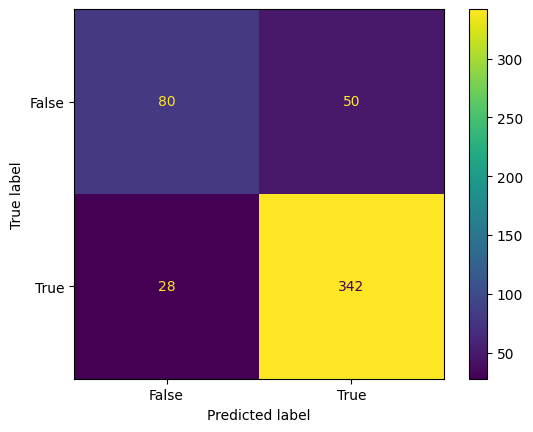

In [36]:
ConfusionMatrixDisplay.from_estimator(lgbm_model, X_test, y_test)